<a href="https://colab.research.google.com/github/JONATANRAP/AI4ENG-Kaggle-JONATAN-ROMERO/blob/main/lab4_parte1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Laboratorio 4 - Parte 1. Redes neuronales artificiales - perceptrón multicapa

## Objetivo general

En este laboratorio el estudiante implementará y comparará redes neuronales artificiales de tipo perceptrón multicapa (MLP) aplicadas a dos tipos de problemas fundamentales en aprendizaje automático:

- **Regresión:** predicción de variables continuas con múltiples salidas usando `MLPRegressor`.
- **Clasificación:** asignación de etiquetas de clase usando `MLPClassifier`.
- **Definición de arquitecturas con PyTorch:** construcción de redes neuronales de forma flexible usando el módulo `nn.Sequential`.

El laboratorio está organizado en cuatro ejercicios:

| Ejercicio | Tipo de problema | Tarea principal |
|-----------|-----------------|-----------------|
| 1 | regresión | Verificar la función de activación de salida e implementar `output_activation` |
| 2 | regresión | Implementar `experimentar_mlpr` y analizar el efecto de la arquitectura sobre el error MAPE |
| 3 | clasificación | Implementar `experimentar_mlpc` y analizar el efecto de la arquitectura sobre el error de clasificación |
| 4 | clasificación | Definir una arquitectura MLP en PyTorch usando `nn.Sequential` |

---

## Fundamento teórico: el perceptrón multicapa (MLP)

Un **perceptrón multicapa** es una red neuronal artificial organizada en capas:

1. **Capa de entrada:** recibe las características de los datos (una neurona por variable).
2. **Capas ocultas:** aprenden representaciones intermedias mediante combinaciones no lineales. Cada neurona calcula: `salida = f(w * x + b)`, donde `f` es la función de activación.
3. **Capa de salida:** produce la predicción final. Su función de activación **depende del tipo de problema**:
   - Para **regresión**: se usa activación lineal (identidad), pues la salida debe ser un valor continuo sin restricción de rango.
   - Para **clasificación**: se usa **softmax** (multiclase) o **sigmoide** (binaria), pues la salida debe interpretarse como una probabilidad entre 0 y 1.

el entrenamiento se realiza mediante **retropropagación del error** (*backpropagation*): se calcula el gradiente de la función de pérdida respecto a cada peso y se actualiza usando un optimizador (tipicamente descenso de gradiente o alguna variante como Adam).

---

## Metodologia de validación

- **Ejercicios 2 y 3:** se usa validación cruzada para estimar el error de generalización del modelo.
  - Ejercicio 2 (regresión): `ShuffleSplit` con 3 particiones aleatorias y 20% de datos para prueba.
  - Ejercicio 3 (clasificación): `StratifiedKFold` con 4 particiones estratificadas, lo que garantiza que cada partición conserve la proporción de clases originales.
- La **semilla aleatoria** (`random_state`) se fija en todos los modelos para garantizar reproducibilidad.

---

## Configuración del entorno

Las siguientes celdas descargan las dependencias del laboratorio e inicializan la sesión del estudiante. Se deben ejecutar en orden antes de comenzar con los ejercicios.

> **Nota:** La celda de login solicitará las credenciales institucionales del estudiante. Es necesario completar este paso para poder registrar las soluciones en línea.

In [1]:
!wget -nc --no-cache -O init.py -q https://raw.githubusercontent.com/jdariasl/Intro_ML_2025/master/init.py
import init; init.init(force_download=False); init.get_weblink()

replicating local resources
replicating Labs resources


In [3]:
from local.lib.rlxmoocapi import submit, session
import inspect
session.LoginSequence(
    endpoint=init.endpoint,
    course_id="introml",
    session_id="udea.vir.20262.g1",
    lab_id="L04.01",
    varname="student"
)

logging in as jonatan.romeroa@udea.edu.co... please wait
you are registered in the following sessions of this course

     ['udea.vir.20261', 'udea.vir.20262.g1']

and you have explicitly requested session 'udea.vir.20262.g1'.
your grades will be reported in that session

-------------
using course session introml::udea.vir.20262.g1
success!! you are logged in
-------------


In [4]:
#configuración del laboratorio
# Ejecuta esta celda!
from Labs.commons.utils.lab4 import *
_ = part_1()

## Conjunto de datos: calidad del aire

Se trabaja con el dataset **AirQuality** del [UCI Machine Learning Repository](https://archive.ics.uci.edu/ml/datasets/Air+Quality), que contiene mediciones horarias de concentración de gases contaminantes y condiciones ambientales en una ciudad italiana.

Para este laboratorio:
- Se usan las primeras 11 columnas como variables de entrada (`x`).
- Se predicen **dos variables de salida simultáneamente** (`y`): columnas 12 y 13 del archivo original.

Este es un ejemplo de **regresión con múltiples salidas**, donde el modelo debe aprender a predecir dos valores continuos a partir del mismo conjunto de entradas. En `sklearn`, `MLPRegressor` soporta este esquema de forma nativa cuando la variable objetivo `Y` es una matriz de forma `(n_muestras, n_salidas)`.

> **esta celda no debe modificarse.** La carga de datos es parte de la configuración del entorno.

In [5]:
#cargamos la bd que está en un archivo .data y ahora la podemos manejar de forma matricial
db = np.loadtxt('Labs/commons/utils/data/AirQuality.data',delimiter='\t')  # Assuming tab-delimiter

#Esta es la base de datos AirQuality del UCI Machine Learning Repository. En el siguiente URL se encuentra toda
#la descripción de la base de datos y la contextualización del problema.
#https://archive.ics.uci.edu/ml/datasets/Air+Quality#

x = db[:,0:11]
y = db[:,11:13]

---

## Ejercicio 1: función de activación en la capa de salida (regresión)

### Concepto

La función de activación de la **capa de salida** es una decisión de diseño crítica en una red neuronal, porque determina el rango de valores que el modelo puede producir:

- **Identidad (lineal):** `f(x) = x`. No impone restricción sobre la salida. Apropiada para regresión, donde los valores pueden ser cualquier número real.
- **Sigmoide:** `f(x) = 1 / (1 + e^(-x))`. Comprime la salida entre 0 y 1. Apropiada para clasificación binaria.
- **Softmax:** normaliza un vector de valores para que sumen 1. Apropiada para clasificación multiclase.
- **Tanh, ReLU:** usadas tipicamente en capas **ocultas**, no en la capa de salida.

Para un problema de regresión como el planteado, la capa de salida **no debe tener función de activación no lineal**, ya que eso limitaria artificialmente el rango de las predicciones.


### Pregunta conceptual

Antes de programar, el estudiante debe responder con sus propias palabras, relacionando la pregunta con el rango de valores de la variable de salida y el tipo de función de activación adecuada.

In [ ]:
#@title Pregunta Abierta
#@markdown ¿De acuerdo al problema planteado, que función de activación debe usar el MLP para un problema de regresión?
respuesta = "" #@param {type:"string"}

Una característica de los modelos de sklearn, es que ciertos tipos de atributos solo pueden ser accedidos cuando se entrena el modelo. Vamos a desarrollar una pequeña función para comprobar cuál es la función de activación de los modelos MLP para regresión de sklearn.

### implementación: función `output_activation`

Esta función crea un `MLPRegressor` con datos aleatorios, lo entrena y retorna la función de activación de su capa de salida. Los pasos son:

1. **Llamar a `mlp.fit(xrandom, yrandom)`** para entrenar el modelo con los datos aleatorios ya definidos. el objetivo no es obtener un buen modelo, sino simplemente forzar el entrenamiento para que el atributo `out_activation_` quede disponible.

2. **Retornar `mlp.out_activation_`**: este atributo es un string que indica el nombre de la función de activación usada en la capa de salida. solo está disponible despues de llamar a `fit`.

> **Importante:** En `sklearn`, muchos atributos de un modelo (terminados en `_`) solo existen despues de entrenarlo. Intentar acceder a `out_activation_` antes de llamar a `fit` generara un error de tipo `NotFittedError`.

In [6]:
def output_activation():
    """funcion que entrena un modelo
    con datos aleatorios para confirmar la función
    de activación de la ultima capa
    """
    mlp = MLPRegressor()

    xrandom = np.random.rand(10,2)
    yrandom = np.zeros(10)

    mlp.fit(xrandom, yrandom)

    return mlp.out_activation_

**Registra tu solución en línea**

In [7]:
student.submit_task(namespace=globals(), task_id='T1');

In [8]:
print("la función de activación para un problema de regresion es:", output_activation())

la función de activación para un problema de regresion es: identity


---

## Ejercicio 2: experimentos con MLP para regresión

### Concepto

En este ejercicio se explora cómo la **arquitectura de la red** (número de capas ocultas y número de neuronas por capa) afecta el error de predicción en un problema de regresión con múltiples salidas.

**Hiperparámetros clave:**

- `hidden_layer_sizes`: tupla que define la arquitectura de las capas ocultas. Por ejemplo, `(16, 16, 16)` indica 3 capas ocultas con 16 neuronas cada una. En este ejercicio, el número de capas y el número de neuronas se pasan como argumentos separados y se combinan dentro de la función.
- `activation`: función de activación en las capas ocultas. Se usara `'tanh'`, que produce salidas entre -1 y 1 y suele funcionar bien cuando los datos están normalizados.
- `max_iter`: número máximo de épocas de entrenamiento. Una época es un recorrido completo por el conjunto de entrenamiento.
- `random_state`: semilla para la inicialización aleatoria de los pesos.

**Metrica de error: MAPE**

el **Error Porcentual Absoluto Medio** (Mean Absolute Percentage Error) mide el error relativo de la predicción:

`MAPE = (1/n) * sum(|y_real - y_pred| / |y_real|) * 100`

Un MAPE de 10% significa que, en promedio, las predicciones se desvian un 10% del valor real. En `sklearn`, la función correspondiente es [`mean_absolute_percentage_error`](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.mean_absolute_percentage_error.html).

como el problema tiene **dos salidas independientes** (`Y1` e `Y2`), el error se calcula por separado para cada columna de `Ytest` y `Yest`.


### implementación: función `experimentar_mlpr`

Dentro del bucle de validación cruzada, se deben completar los siguientes fragmentos:

1. **Construir `hidden_layer_sizes`**: se debe crear una tupla de longitud `hidden_layers` donde cada elemento sea `neurons`. Por ejemplo, si `hidden_layers=2` y `neurons=16`, el resultado debe ser `(16, 16)`. Esto se logra con la expresión `tuple(hidden_layers * [neurons])`.

2. **Instanciar `MLPRegressor`** con los siguientes parámetros (todos por nombre):
   - `hidden_layer_sizes`: la tupla construida en el paso anterior.
   - `activation='tanh'`: función de activación de las capas ocultas.
   - `max_iter=300`: número máximo de épocas.
   - `random_state=1`: semilla para reproducibilidad.

3. **Entrenar el modelo** llamando a `mlp.fit(Xtrain, Ytrain)`.

4. **Predecir sobre el conjunto de prueba**: `Yest = mlp.predict(Xtest)`. el resultado es una matriz de forma `(n_test, 2)`.

5. **Calcular el MAPE para cada salida** usando `mean_absolute_percentage_error`. La función acepta los vectores reales y predichos como argumentos. como `Ytest` e `Yest` son matrices, se debe pasar la columna correspondiente: `Ytest[:, 0]` para Y1 y `Ytest[:, 1]` para Y2.

> **Sobre la normalización:** el scaler se ajusta solo con `Xtrain` y luego se aplica a `Xtest`. Esto evita la **fuga de información** (*data leakage*): si el scaler se ajustara con todos los datos, el modelo "vería" información del conjunto de prueba durante el entrenamiento, sesgando la estimacion del error.

In [14]:
def experimentar_mlpr(num_hidden_layers, num_neurons, X,Y):

    Folds = 3
    ss = ShuffleSplit(n_splits=Folds, test_size=0.2, random_state=1)
    resultados = pd.DataFrame()
    idx = 0

    for hidden_layers in num_hidden_layers:
        for neurons in num_neurons:

            for j, (train, test) in enumerate(ss.split(X)):

                # para almacenar errores intermedios
                ErrorY1 = np.zeros(Folds)
                ErrorY2 = np.zeros(Folds)

                Xtrain = X[train,:]
                Ytrain = Y[train,:]
                Xtest = X[test,:]
                Ytest = Y[test,:]

                # Normalizamos los datos
                scaler = StandardScaler().fit(X=Xtrain)
                Xtrain = scaler.transform(Xtrain)
                Xtest = scaler.transform(Xtest)

                # Crear arquitectura
                hidden_layer_sizes = tuple(hidden_layers * [neurons])

                # Crear modelo
                mlp = MLPRegressor(
                    hidden_layer_sizes=hidden_layer_sizes,
                    activation='tanh',
                    max_iter=300,
                    random_state=1
                )

                # Entrenar
                mlp.fit(Xtrain, Ytrain)

                # Predecir
                Yest = mlp.predict(Xtest)

                # Error
                errors = [
                    mean_absolute_percentage_error(Ytest[:,0], Yest[:,0]),
                    mean_absolute_percentage_error(Ytest[:,1], Yest[:,1])
                ]

                ErrorY1[j] = errors[0]
                ErrorY2[j] = errors[1]

            print('error para salida 1 = ' + str(np.mean(ErrorY1)) + '+-' + str(np.std(ErrorY1)))
            print('error para salida 2 = ' + str(np.mean(ErrorY2)) + '+-' + str(np.std(ErrorY2)))

            resultados.loc[idx,'capas ocultas'] = hidden_layers
            resultados.loc[idx,'neuronas en capas ocultas'] = neurons
            resultados.loc[idx,'error de prueba y1(media)'] = np.mean(ErrorY1)
            resultados.loc[idx,'intervalo de confianza y1'] = np.std(ErrorY1)
            resultados.loc[idx,'error de prueba y2(media)'] = np.mean(ErrorY2)
            resultados.loc[idx,'intervalo de confianza y2'] = np.std(ErrorY2)

            idx += 1

    return resultados

**Registra tu solución en línea**

In [15]:
student.submit_task(namespace=globals(), task_id='T2');

### Experimentos: arquitectura y error de regresión

La siguiente celda ejecuta los experimentos con todas las combinaciones de `num_hidden_layers = [1, 2, 3]` capas ocultas y `num_neurons = [8, 12, 16]` neuronas por capa. el total de configuraciónes es 9, evaluadas cada una con 3 particiones aleatorias.

> **Advertencia:** esta celda puede tardar varios minutos en ejecutarse debido al número de combinaciónes y al limite de épocas de cada modelo.

In [18]:
# tarda unos minutos!!
resultados_mlpr = experimentar_mlpr(num_hidden_layers = [1,2,3], num_neurons  = [8,12,16], X=x, Y=y)

error para salida 1 = 0.054940292674105225+-0.07769730702046682
error para salida 2 = 2.303548907207818+-3.2577101061630187
error para salida 1 = 0.04964198413271192+-0.07020436722359118
error para salida 2 = 2.2887647148779613+-3.236802100861403
error para salida 1 = 0.03912619726226465+-0.055332798812379735
error para salida 2 = 1.1681283933502844+-1.6519830164690659
error para salida 1 = 0.04179658907180967+-0.059109303126288336
error para salida 2 = 1.5148277026141408+-2.1422898816953957
error para salida 1 = 0.039520652473079364+-0.055890642721262644
error para salida 2 = 1.9538747891696877+-2.763196226022644
error para salida 1 = 0.03634624290884996+-0.05140134966300255
error para salida 2 = 1.6746353803181373+-2.368292066875736
error para salida 1 = 0.06171514336384773+-0.08727839274895337
error para salida 2 = 2.2963026385629104+-3.247462334768792
error para salida 1 = 0.037203616971060643+-0.052613859689807814
error para salida 2 = 1.9308785871560854+-2.7306746852519366
error 

### Visualización de resultados

Las graficas muestran como varía el error de prueba de cada salida en función del número de neuronas, diferenciando por número de capas (estilo de linea). el estudiante debe observar:
- Si aumentar la profundidad (número de capas) reduce el error de forma consistente.
- Si aumentar el número de neuronas mejora o empeora el error.
- Si alguna configuración presenta signos de sobreajuste (error de entrenamiento mucho menor que el de prueba).

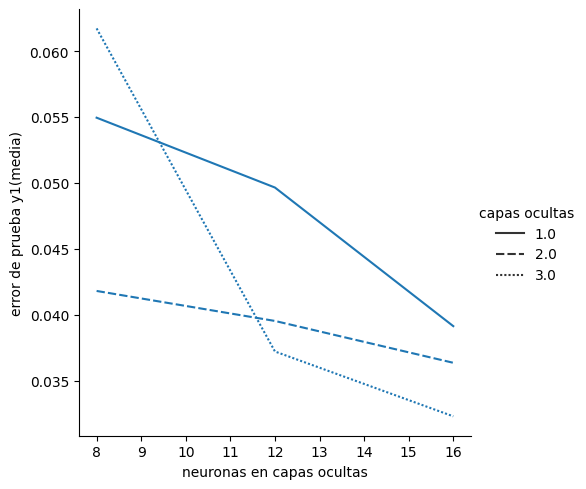

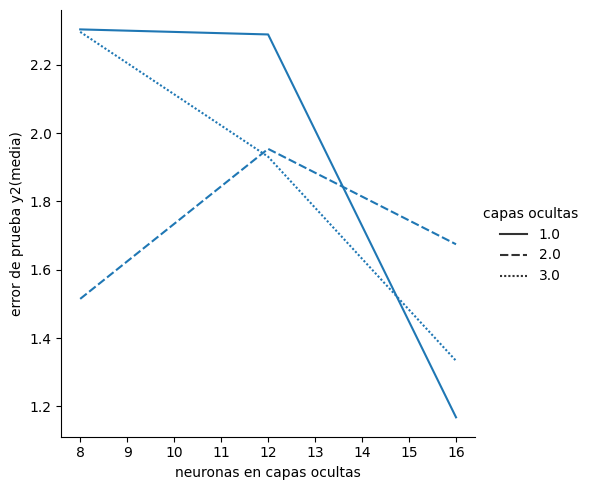

In [19]:
# ver los resultados.
import seaborn as sns
sns.relplot(data = resultados_mlpr,  x='neuronas en capas ocultas', y = 'error de prueba y1(media)', style= 'capas ocultas', kind = 'line')
sns.relplot(data = resultados_mlpr,  x='neuronas en capas ocultas', y = 'error de prueba y2(media)', style= 'capas ocultas', kind = 'line')
plt.show()

### Pregunta conceptual: efecto de la semilla aleatoria

Reflexiona sobre el rol del parámetro `random_state` en la inicialización de los pesos de la red y en la partición de los datos, y justificar si resultados obtenidos con distintas semillas son comparables entre si.

In [ ]:
#@title Pregunta Abierta
#@markdown Qué ocurre si cambiamos el valor de random state? ¿deberían los resultados ser iguales?
respuesta = "" #@param {type:"string"}

---

## Ejercicio 3: experimentos con MLP para clasificación

La diferencia fundamental entre un MLP para regresión y uno para clasificación no está en las capas ocultas, sino en la **capa de salida** y en la **función de pérdida** utilizada durante el entrenamiento:

| Aspecto | regresión | clasificación multiclase |
|---------|-----------|--------------------------|
| activación de salida | Identidad (lineal) | Softmax |
| número de neuronas de salida | Igual al número de salidas (2 en este caso) | Igual al número de clases |
| función de pérdida | Error cuadratico medio (MSE) | Entropia cruzada (cross-entropy) |
| Metrica de evaluación | MAPE, MSE, MAE | Exactitud (accuracy), F1-score |

Para clasificación multiclase, la **softmax** convierte el vector de salida en una distribución de probabilidad sobre las clases: cada neurona de salida representa la probabilidad de que la muestra pertenezca a esa clase.

el **error de clasificación** se define como `1 - exactitud`, donde la exactitud es la proporción de muestras clasificadas correctamente.

### Conjunto de datos: digitos escritos a mano

Se usa el dataset `digits` de `sklearn` con las primeras 4 clases (digitos 0, 1, 2 y 3). Los datos se preprocesan con PCA conservando el 99% de la varianza con blanqueamiento, igual que en el laboratorio anterior.

> **¿por qué se usa `StratifiedKFold` en clasificación y `ShuffleSplit` en regresión?** En clasificación, si las clases están desbalanceadas, una partición aleatoria sin estratificacion puede colocar casi todas las muestras de una clase en entrenamiento o en prueba, distorsionando la evaluación. `StratifiedKFold` garantiza que cada partición conserve la proporción de clases del conjunto original. En regresión no existe este problema porque las etiquetas son continuas.

In [20]:
digits = load_digits(n_class=4)
#--------- preprocesamiento--------------------
pca = PCA(0.99, whiten=True)
data = pca.fit_transform(digits.data)
#---------- Datos a usar ----------------------
Xd = data
Yd = digits.target

### Pregunta conceptual: función de activación de salida para clasificación

Antes de programar, el estudiante debe indicar que función de activación es adecuada para la capa de salida de un clasificador y justificar su eleccion en términos del tipo de salida que produce (valores entre 0 y 1, suma igual a 1, etc.).

In [ ]:
#@title Pregunta Abierta
#@markdown  ¿Qué tipo de función de activación debe usar el modelo en la capa de salida para un problema de clasificación?
respuesta = "" #@param {type:"string"}

como lo hicmos antes, vamos a comprobar con la libreria la función de activación

### Implementación: función `output_activation_MPC`

Esta función es análoga a `output_activation` del Ejercicio 1, pero para `MLPClassifier`. Los pasos son:

1. **Llamar a `mlp.fit(xrandom, yrandom)`** con los datos aleatorios ya definidos en el cuerpo de la función.

2. **Retornar el objeto `mlp`**: a diferencia del Ejercicio 1, aqui se retorna el modelo completo para que la celda de verificación pueda acceder a sus atributos. el estudiante puede inspeccionar `mlp.out_activation_` despues de retornar el objeto para confirmar la función de activación usada.

> **Nota:** `yrandom = np.zeros(10)` define 10 muestras de la misma clase (clase 0). Esto es suficiente para que `MLPClassifier` entrene y exponga sus atributos internos, aunque el modelo resultante no sera util para clasificar.

In [21]:
def output_activation_MPC():
    """funcion que entrena un modelo
    con data aleatoria para confirmar la funcion
    de activacion de la ultima capa
    """
    mlp = MLPClassifier()

    # fit with some random data
    xrandom = np.random.rand(10,2)
    yrandom = np.zeros(10)

    # entrenar el MLP
    mlp.fit(xrandom, yrandom)

    # retornar el modelo
    return (mlp)

In [22]:
print("la función de activación para un problema de clasificación es:", output_activation_MPC())

la función de activación para un problema de clasificación es: MLPClassifier()


Ahora en nuestro siguiente ejercicio vamos a implementar una red neuronal artificial de tipo perceptrón multicapa (MLP) para resolver un problema de clasificación.

### Implementación: función `experimentar_mlpc`

La estructura de esta función es identica a `experimentar_mlpr`, pero adaptada para clasificación. Se deben completar los siguientes fragmentos:

1. **Construir `hidden_layer_sizes`**: igual que en el ejercicio anterior, `tuple(hidden_layers * [neurons])`. está es la forma estándar de crear una arquitectura uniforme (todas las capas con el mismo número de neuronas).

2. **Instanciar `MLPClassifier`** con los siguientes parámetros (todos por nombre):
   - `hidden_layer_sizes`: la tupla construida.
   - `activation='relu'`: función de activación ReLU para las capas ocultas. ReLU (`max(0, x)`) es eficiente computacionalmente y ayuda a evitar el problema del gradiente evanescente en redes profundas.
   - `max_iter=350`: número máximo de épocas.
   - `random_state=1`: semilla para reproducibilidad.

3. **Entrenar el modelo**: `mlp.fit(Xtrain, Ytrain)`.

4. **Predecir sobre el conjunto de prueba**: `Yest = mlp.predict(Xtest)`.

5. **Calcular el error de clasificación**: la instruccion pide usar `accuracy_score` del módulo de métricas de sklearn, pero la función debe **retornar el error** (no la exactitud). Por lo tanto, el cálculo correcto es `Error[j] = 1 - accuracy_score(Ytest, Yest)`.

> **¿por qué se guarda el error y no la exactitud?** Por convención, en la literatura de aprendizaje automático se trabaja con el error (que se minimiza), no con la exactitud (que se maximiza). Esto facilita comparar modelos y graficar curvas de aprendizaje de forma consistente.

In [23]:
def experimentar_mlpc(X,Y, num_hidden_layers, num_neurons):
    """ función para realizar experimentos con el MLP
    x: matriz de numpy con las muestras de entrada [muestras,variables]
    y: vector numpy con las variables a predecir
    num_hidden_layers: list de enteros con el número de capas
        ocultas a usar
    num_neurons: list de enteros con el número de neuronas a usar

    Retorna: dataframe con 4 columnas:
        - número de capas, número de neuronas
        - promedio de error prueba (1 - exactitud/eficiencia) de claisficación y desviación estandar
    """

    # Validamos el modelo
    Folds = 4
    skf = StratifiedKFold(n_splits=Folds)
    resultados = pd.DataFrame()
    idx = 0

    for hidden_layers in num_hidden_layers:
        for neurons in num_neurons:

            for j, (train, test) in enumerate(skf.split(X, Y)):

                # para almacenar errores intermedios
                Error = np.zeros(Folds)

                Xtrain = X[train,:]
                Ytrain = Y[train]
                Xtest = X[test, :]
                Ytest = Y[test]

                # Normalizamos los datos
                scaler = StandardScaler().fit(X=Xtrain)
                Xtrain = scaler.transform(Xtrain)
                Xtest = scaler.transform(Xtest)

                # Construimos la arquitectura
                hidden_layer_sizes = tuple(hidden_layers * [neurons])

                # Creamos el MLP
                mlp = MLPClassifier(
                    hidden_layer_sizes=hidden_layer_sizes,
                    activation='relu',
                    max_iter=350,
                    random_state=1
                )

                # Entrenamos el MLP
                mlp.fit(Xtrain, Ytrain)

                # Predicciones
                Yest = mlp.predict(Xtest)

                # Error de clasificación
                Error[j] = 1 - accuracy_score(Ytest, Yest)

            print('error para configuracion de params = ' + str(np.mean(Error)) + '+-' + str(np.std(Error)))

            resultados.loc[idx,'capas ocultas'] = hidden_layers
            resultados.loc[idx,'neuronas en capas ocultas'] = neurons
            resultados.loc[idx,'error de prueba(media)'] = np.mean(Error)
            resultados.loc[idx,'intervalo de confianza'] = np.std(Error)

            idx += 1

    return (resultados)

**Registra tu solución en línea**

In [24]:
student.submit_task(namespace=globals(), task_id='T3');

### Experimentos y visualización

La siguiente celda ejecuta los experimentos con `num_hidden_layers = [1, 2, 3]` y `num_neurons = [12, 16, 20]`. La grafica resultante muestra como el error de prueba varía con el número de neuronas y capas.

el estudiante debe observar:
- Si una arquitectura más profunda (más capas) reduce el error de clasificación de forma consistente.
- Si existe un punto a partir del cual agregar más neuronas deja de mejorar (o incluso empeora) el desempeño.
- La diferencia entre usar `relu` (ejercicio 3) y `tanh` (ejercicio 2) como función de activación oculta, en términos del comportamiento del entrenamiento.

In [26]:
# tarda unos minutos!!
resultados_mlpc = experimentar_mlpc(X = Xd, Y=Yd, num_hidden_layers=[1,2,3], num_neurons=[12,16,20])

error para configuracion de params = 0.022222222222222227+-0.03849001794597506
error para configuracion de params = 0.020833333333333343+-0.03608439182435163
error para configuracion de params = 0.02638888888888888+-0.04570689631084535
error para configuracion de params = 0.033333333333333326+-0.05773502691896256
error para configuracion de params = 0.02361111111111111+-0.04089564406759849
error para configuracion de params = 0.03194444444444444+-0.05532940079733913
error para configuracion de params = 0.02777777777777779+-0.048112522432468836
error para configuracion de params = 0.02777777777777779+-0.048112522432468836
error para configuracion de params = 0.030555555555555558+-0.0529237746757157


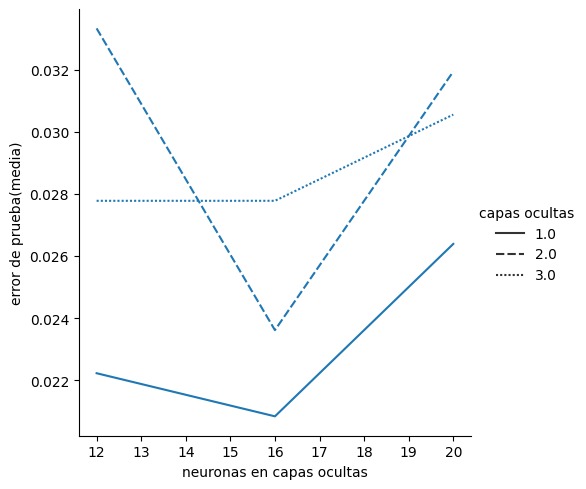

In [27]:
# ver los resultados
# notar como las capas ocultas y el # de neuronas influyen
import seaborn as sns
sns.relplot(data = resultados_mlpc,  x='neuronas en capas ocultas', y = 'error de prueba(media)', style= 'capas ocultas', kind = 'line')
plt.show()

### Pregunta conceptual: neuronas en la capa de salida

La siguiente pregunta apunta a comprender la relación entre la arquitectura de la capa de salida y el problema de clasificación. el estudiante debe indicar cuántas neuronas tiene la capa de salida del modelo y explicar por qué ese número es el correcto, relacionandolo con el número de clases del problema y el esquema de activación softmax.

In [ ]:
#@title Pregunta Abierta
#@markdown ¿Cuántas neuronas en la capa de salida tiene el modelo? ¿Porqué debe tener ese número?
respuesta = "" #@param {type:"string"}

---

## Ejercicio 4: arquitectura MLP en PyTorch

### Concepto

`sklearn` ofrece una implementación sencilla de MLP, pero con opciones limitadas de personalizacion. **PyTorch** es un framework de aprendizaje profundo que permite definir arquitecturas arbitrarias, funciones de pérdida personalizadas y procedimientos de entrenamiento a medida. Es ampliamente usado en investigacion y produccion.

En PyTorch, una red neuronal se define como una secuencia de **módulos** (capas y activaciones). el módulo `nn.Sequential` permite encadenar módulos en orden: la salida de cada módulo es la entrada del siguiente.

**Conceptos clave:**

- **`nn.Linear(in_features, out_features)`**: capa densa (completamente conectada). Realiza la transformación `y = Wx + b`. Requiere conocer el número de entradas (`in_features`) y el número de salidas (`out_features`) de cada capa.
- **`nn.ReLU()`**: capa de activación ReLU. Se inserta despues de cada capa lineal oculta.
- **No se incluye la activación de la capa de salida**: en PyTorch, cuando se usa `CrossEntropyLoss`, la función softmax se aplica internamente. Incluirla manualmente causaria un cálculo doble y resultados incorrectos.


### Implementación: función `MLP_classifier_pytorch`


La función recibe:
- `X`: tensor de entrenamiento de forma `(n_muestras, n_caracteristicas)`. el número de características determina el tamaño de la primera capa.
- `Y`: tensor de etiquetas. el número de clases únicas determina el tamaño de la última capa.
- `neurons_per_layer`: lista de enteros donde cada elemento indica el número de neuronas de una capa oculta.

el estudiante debe construir la lista `modules` iterando sobre `neurons_per_layer`. Para cada capa oculta, se deben agregar dos módulos a la lista:
1. Una capa `nn.Linear(in_features, out_features)` donde `in_features` es la dimension de la capa anterior y `out_features` es el número de neuronas de la capa actual.
2. Una activación `nn.ReLU()`.

Al finalizar el bucle, se agrega la **capa de salida** (`nn.Linear`) con `in_features` igual al número de neuronas de la última capa oculta y `out_features` igual al número de clases.

**Estrategia para calcular `in_features` en cada iteración:**
- Para la primera capa oculta: `in_features = X.shape[1]` (número de características de entrada).
- Para las capas siguientes: `in_features` es el número de neuronas de la capa oculta anterior.
- Una forma sencilla es mantener una variable `in_dim` que se actualiza en cada iteración.

**Estrategia para calcular el número de clases:**
- `len(torch.unique(Y))` retorna el número de clases únicas en el vector de etiquetas.

> **por qué no se incluye softmax en el modelo?** `CrossEntropyLoss` de PyTorch combina internamente `LogSoftmax` y `NLLLoss`. Si se incluye una activación softmax en el modelo, la función de pérdida aplicaria softmax dos veces, produciendo gradientes incorrectos y un entrenamiento defectuoso.

In [30]:
def MLP_classifier_pytorch(X, Y, neurons_per_layer):
    """
    Entrada:

    X: matriz de numpy con las muestras de entrada [muestras,variables]

    Y: vector numpy con las variables a predecir

    neurons_per_layer: list de enteros con el número de neuronas a usar por
    cada una de las capas ocultas

    Retorna:

    Modelo de PyTorch con la arquitectura deseada
    """

    import torch
    import torch.nn as nn

    modules = []

    # Número de características de entrada
    in_dim = X.shape[1]

    # Construcción de las capas ocultas
    for neurons in neurons_per_layer:
        modules.append(nn.Linear(in_dim, neurons))
        modules.append(nn.ReLU())

        # Actualizamos la dimensión para la siguiente capa
        in_dim = neurons

    # Número de clases
    num_classes = len(torch.unique(torch.tensor(Y)))

    # Capa de salida
    modules.append(nn.Linear(in_dim, num_classes))

    model = nn.Sequential(*modules)

    return model


**Registra tu solución en línea**

In [31]:
student.submit_task(namespace=globals(), task_id='T4');

### Experimento: entrenamiento con PyTorch

La siguiente celda entrena el modelo definido en el ejercicio anterior usando descenso de gradiente estocastico (SGD) con momento. el estudiante debe observar como la pérdida (`loss`) disminuye a lo largo de las épocas, lo que indica que el modelo está aprendiendo.

**Aspectos a notar en el codigo de entrenamiento:**
- `optimizer.zero_grad()`: limpia los gradientes acumulados del paso anterior. Es obligatorio llamarlo antes de `loss.backward()`.
- `loss.backward()`: calcula los gradientes por retropropagación.
- `optimizer.step()`: actualiza los pesos usando los gradientes calculados.
- `model.eval()`: cambia el modelo a modo de evaluación (desactiva dropout y batch normalization si los hubiera).
- `torch.argmax(Yest, axis=1)`: convierte el vector de probabilidades de salida en la clase predicha (la de mayor probabilidad).

> **Nota:** el bucle de entrenamiento que se muestra aqui es la forma manual de entrenar en PyTorch. En proyectos reales se suelen usar frameworks de alto nivel como `pytorch-lightning` que automatizan este proceso.

In [32]:
#Experimentar con el modelo creado en PyTorch
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
import torch


#Data partition
train_indx, test_indx = train_test_split(np.arange(Xd.shape[0]), train_size=0.7, random_state=1)
Xtrain = Xd[train_indx,:]
Ytrain = Yd[train_indx]
Xtest = Xd[test_indx,:]
Ytest = Yd[test_indx]

#Normalization
scaler = StandardScaler().fit(X= Xtrain)
Xtrain = scaler.transform(Xtrain)
Xtest = scaler.transform(Xtest)

#Tensor transformation
Xtrain = torch.tensor(Xtrain, dtype=torch.float32)
Ytrain = torch.tensor(Ytrain, dtype=torch.long)
Xtest = torch.tensor(Xtest, dtype=torch.float32)

#Set the loss function
#En PyTorch la función de crossentropia aplica la activación Softmax, por eso no
# se debe incluir en la construcción del modelo.
loss_fn = torch.nn.CrossEntropyLoss()

model = MLP_classifier_pytorch(X = Xtrain, Y=Ytrain, neurons_per_layer=[20,10])

#Definimos el optimizador
optimizer = torch.optim.SGD(model.parameters(), lr=0.1, momentum=0.9)

max_epochs = 100
model.train()
for i in range(max_epochs):
  out_put = model(Xtrain)
  loss = loss_fn(out_put, Ytrain)
  print(f'epoch = {i}, loss = {loss}')
  optimizer.zero_grad()
  loss.backward()
  optimizer.step()

model.eval()
Yest = model(Xtest)
Yest = torch.argmax(Yest, axis=1)
print(f'Test accuracy = {accuracy_score(Ytest, Yest)}')

epoch = 0, loss = 1.4085121154785156
epoch = 1, loss = 1.4060217142105103
epoch = 2, loss = 1.4015012979507446
epoch = 3, loss = 1.3954943418502808
epoch = 4, loss = 1.3885588645935059
epoch = 5, loss = 1.3812401294708252
epoch = 6, loss = 1.373895525932312
epoch = 7, loss = 1.3665032386779785
epoch = 8, loss = 1.3591290712356567
epoch = 9, loss = 1.3515514135360718
epoch = 10, loss = 1.3433425426483154
epoch = 11, loss = 1.3341374397277832
epoch = 12, loss = 1.3234597444534302
epoch = 13, loss = 1.310866355895996
epoch = 14, loss = 1.2958158254623413
epoch = 15, loss = 1.2775977849960327
epoch = 16, loss = 1.2552146911621094
epoch = 17, loss = 1.2277557849884033
epoch = 18, loss = 1.1938315629959106
epoch = 19, loss = 1.1520204544067383
epoch = 20, loss = 1.1004887819290161
epoch = 21, loss = 1.0376094579696655
epoch = 22, loss = 0.9620651602745056
epoch = 23, loss = 0.8728671669960022
epoch = 24, loss = 0.7707244157791138
epoch = 25, loss = 0.6586454510688782
epoch = 26, loss = 0.542